##  1)Intro

 #### a)Приведите 5 примеров применения методов машинного обучения в жизни. В чем заключается преимущество использования методов машинного обучения в каждом из ваших примеров?

1)Кредитный скоринг в банках  
Модель оценивает вероятность возврата кредита на основе данных о клиенте.
Преимущество: быстрые и более объективные решения по сравнению с ручной оценкой.  
2)Рекомендательные системы  
Методы ML анализируют историю просмотров пользователя и предлагают похожий контент.
Преимущество: экономят время на поиск и повышают удобство использования сервиса.  
3)Фильтрация спама в электронной почте  
Алгоритмы классифицируют письма на «спам» и «не спам» по их содержанию и другим признакам.
Преимущество: защищают пользователя от нежелательных и вредоносных сообщений.  
4)Медицинская диагностика  
ML-модели анализируют снимки (рентген, МРТ) и помогают выявлять заболевания.
Преимущество: повышение точности диагностики и обнаружение болезней на ранних стадиях.  
5)Навигация и прогноз пробок  
Алгоритмы обрабатывают данные о трафике и строят оптимальные маршруты.
Преимущество: сокращение времени в пути и более эффективное планирование маршрута.  

#### b)Используйте классификацию задач, представленную во введении, чтобы определить, к какому классу можно отнести задачи из таблицы выше и 5 приведенных вами примеров.

**Supervised:**
Classification:2,4,5,6,8,10,my1,my3  
Regression: 1,3,2,7,my1,my5  

    
**Unsupervised:**
Clustering:5,my4  
Association:5,7,my2  
Dimensionality reduction (or generalization): 5  

#### c)Think about what the difference is between multiclass and multilabel.

При мульклассовой класификации  выбирается класс, к которому отнесется определенный объект, один объект может отнестись только к одному классу. А при miltilabel объект мы можем отнести к нескольким группам одновременно(например завтрашняя погода, может быть и ветренная и дождливая).

#### Можно ли считать пример с ценами на жилье из теории классификацией задачи регрессии? Возможно ли свести задачу регрессии к задаче классификации?

Да, можно это считать задачей регрессии. И при этом можно сделать через классификацию. Например разделить таргеты по категориям(дешево, средне, дорого) и таким образом классифицировать данные по этим группам.

## 2)Введение в анализ данных

#### IMPORT

In [3]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 640.0 kB/s eta 0:00:03
   - -------------------------------------- 0.1/1.5 MB 656.4 kB/s eta 0:00:03
   -- ------------------------------------- 0.1/1.5 MB 737.3 kB/s eta 0:00:02
   ---- ----------------------------------- 0.2/1.5 MB 952.6 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.5 MB 981.9 kB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.5 MB 1.0 MB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.5 MB 1.0 MB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.5 MB 1.0 MB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.5 MB 1.1 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------- ----------------------- 0.6/1.5 MB 1.2 MB/s eta 0:00:01
   ------------------ --------------------- 0.7/1.5 MB 1.2 MB/s eta 0:00:01
   ------

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score
import lightgbm as lgb
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_json('data/train.json')
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [3]:
df.shape

(49352, 15)

In [4]:
df.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

**Целевой столбец это цена(price)**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [6]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [7]:
df.corr

<bound method DataFrame.corr of         bathrooms  bedrooms                       building_id  \
4             1.0         1  8579a0b0d54db803821a35a4a615e97a   
6             1.0         2  b8e75fc949a6cd8225b455648a951712   
9             1.0         2  cd759a988b8f23924b5a2058d5ab2b49   
10            1.5         3  53a5b119ba8f7b61d4e010512e0dfc85   
15            1.0         0  bfb9405149bfff42a92980b594c28234   
...           ...       ...                               ...   
124000        1.0         3  92bbbf38baadfde0576fc496bd41749c   
124002        1.0         2  5565db9b7cba3603834c4aa6f2950960   
124004        1.0         1  67997a128056ee1ed7d046bbb856e3c7   
124008        1.0         2  3c0574a740154806c18bdf1fddd3d966   
124009        1.0         3  d89f514c3ed0abaae52cba7017ac0701   

                    created  \
4       2016-06-16 05:55:27   
6       2016-06-01 05:44:33   
9       2016-06-14 15:19:59   
10      2016-06-24 07:54:24   
15      2016-06-28 03:50:23   
.

**Пустых столбцов нет**

In [8]:
df_selected = df[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df_selected

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


#### 3)Статистический анализ данных

**Постройте гистограмму**

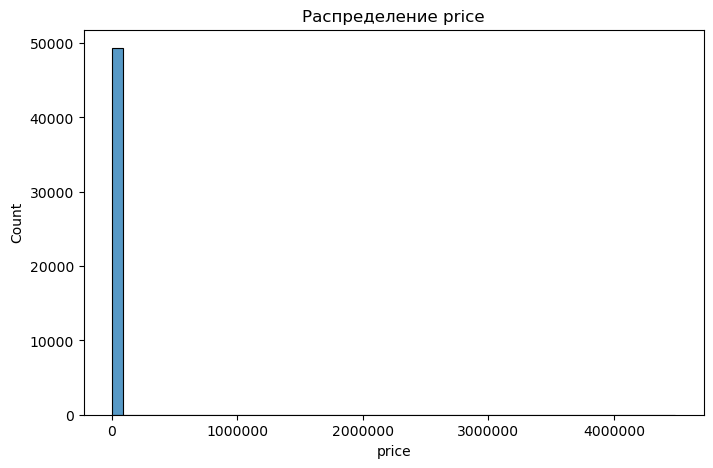

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_selected['price'], bins=50)
plt.ticklabel_format(style='plain', axis='x')#убираем сокращение чисел по x
plt.title('Распределение price')
plt.show()

Большинство данных сосредоточено в низком диапазоне цен.   
Поэтому:  
первый или первые несколько бинов получают огромную высоту,  
а бины с редкими выбросами почти пустые.

**Построение диаграммы размаха:**

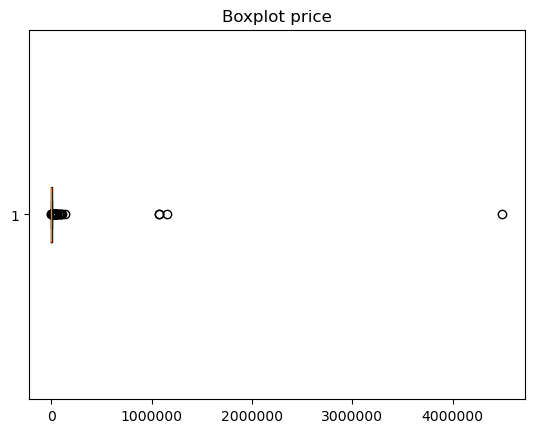

In [10]:
plt.boxplot(df_selected['price'], vert = False)
plt.title('Boxplot price')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

Есть 3 выброса

**Удалите из целевого столбца строки, находящиеся за пределами 1-го и 99-го процентилей.**

In [11]:
q1 = df_selected['price'].quantile(0.01)
q99 = df_selected['price'].quantile(0.99)
df_selected = df_selected[(df_selected['price'] >= q1) & (df_selected['price'] <= q99)]

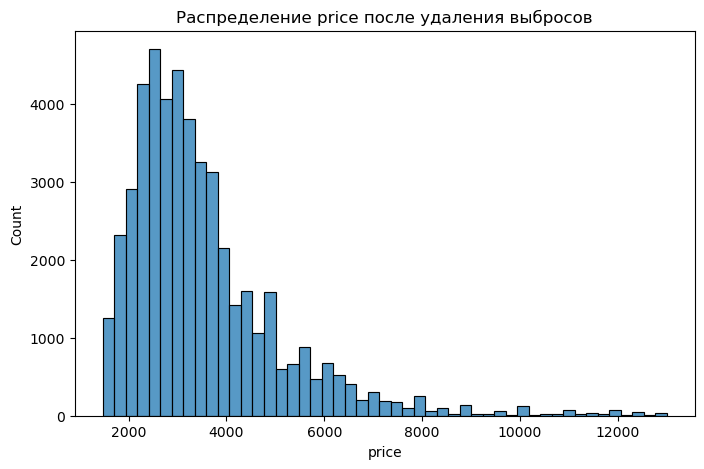

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df_selected['price'], bins=49)
plt.ticklabel_format(style='plain', axis='x')#убираем сокращение чисел по x
plt.title('Распределение price после удаления выбросов')
plt.show()

После удаления значений за пределами 1-го и 99-го процентилей распределение цены стало более наглядным. Ранее выбросы растягивали шкалу, из-за чего основная масса данных была сжата

**Анализ характеристик:**

In [13]:
print("Тип - объект(object)")
df_selected['interest_level'].dtype

Тип - объект(object)


dtype('O')

In [14]:
df_selected['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [15]:
df_selected.loc[:, 'interest_level'] = df_selected['interest_level'].map({
    'low': 0,
    'medium': 1,
    'high': 2
})

In [16]:

df_selected['interest_level']

4         1
6         0
9         1
10        1
15        0
         ..
124000    0
124002    1
124004    1
124008    1
124009    2
Name: interest_level, Length: 48379, dtype: object

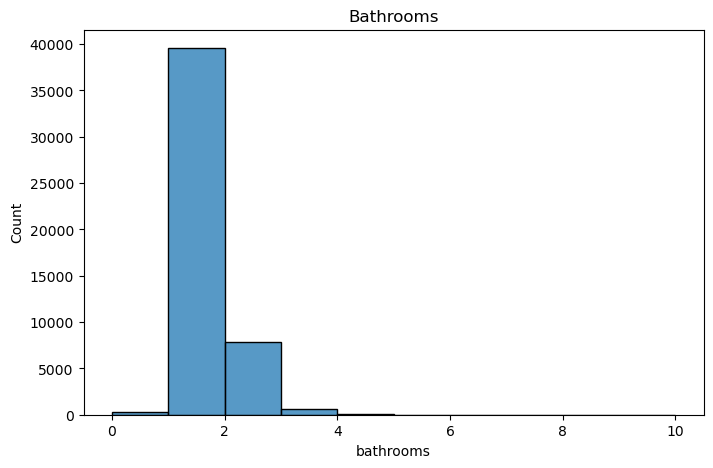

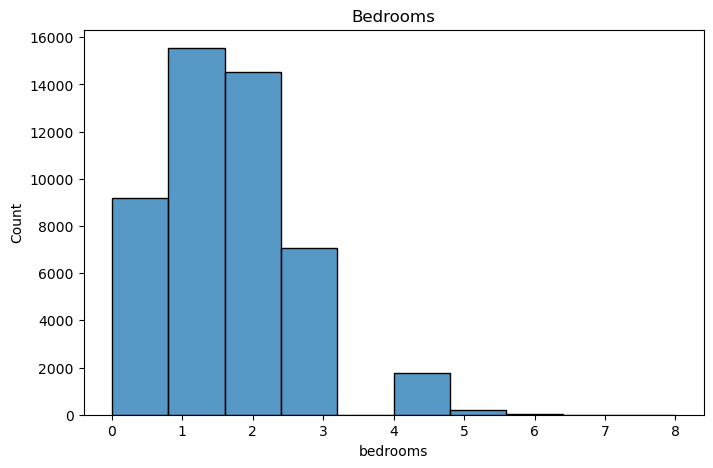

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df_selected['bathrooms'], bins=10)
plt.title('Bathrooms')

plt.figure(figsize=(8,5))
sns.histplot(df_selected['bedrooms'], bins=10)
plt.title('Bedrooms')
plt.show()

**Выбросов для ванных комнат и спален нет**

In [18]:
#Корреляционная матрица
corr = df_selected.corr()
corr

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


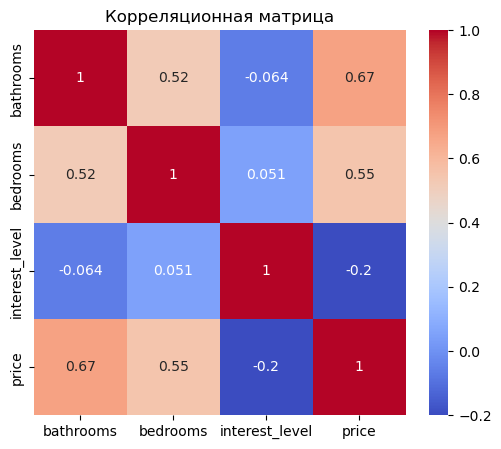

In [19]:
#Тепловая карта
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Наибольшая корреляция наблюдается между ценой (price) и количеством ванных комнат (bathrooms). 

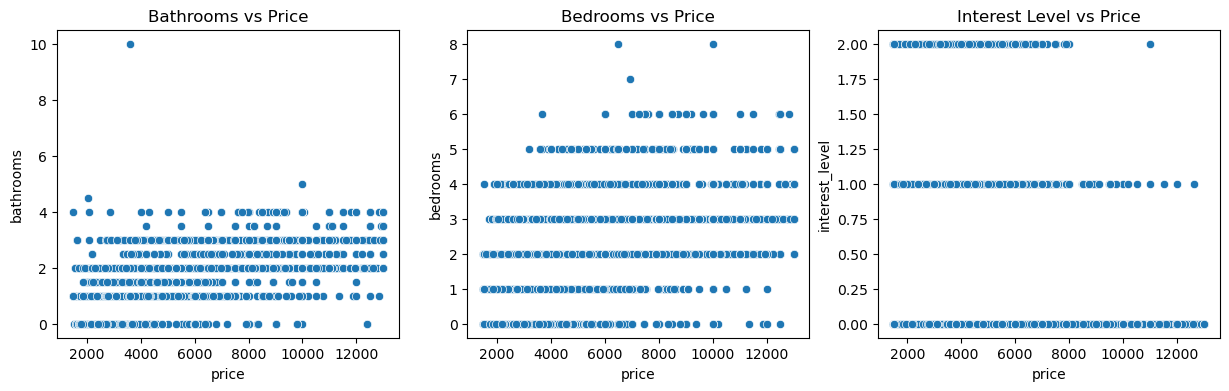

In [20]:
#диаграмма рассеяния
plt.figure(figsize=(15,4))

# bathrooms vs price
plt.subplot(1,3,1)
sns.scatterplot(x=df_selected['price'], y=df_selected['bathrooms'])
plt.title('Bathrooms vs Price')

#bedrooms vs price
plt.subplot(1,3,2)
sns.scatterplot(x=df_selected['price'], y=df_selected['bedrooms'])
plt.title('Bedrooms vs Price')

#interest_level vs price
plt.subplot(1,3,3)
sns.scatterplot(x=df_selected['price'], y=df_selected['interest_level'])
plt.title('Interest Level vs Price')

plt.show()

#### 4)Создание функций

In [21]:
df_selected = df_selected.copy()

In [22]:
df_selected.loc[:, 'bathrooms_squared'] = df_selected['bathrooms'] ** 2
df_selected.loc[:, 'bedrooms_squared'] = df_selected['bedrooms'] ** 2
df_selected.loc[:, 'interest_level_squared'] = df_selected['interest_level'] ** 2

In [23]:
corr = df_selected.corr()
corr

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517574,-0.063635,0.671943,0.956023,0.548760,-0.059410
bedrooms,0.517574,1.000000,0.050654,0.545948,0.478817,0.928277,0.039511
interest_level,-0.063635,0.050654,1.000000,-0.200111,-0.068558,0.046340,0.944013
price,0.671943,0.545948,-0.200111,1.000000,0.648486,0.543406,-0.182672
bathrooms_squared,0.956023,0.478817,-0.068558,0.648486,1.000000,0.522227,-0.062240
bedrooms_squared,0.548760,0.928277,0.046340,0.543406,0.522227,1.000000,0.035718
interest_level_squared,-0.059410,0.039511,0.944013,-0.182672,-0.062240,0.035718,1.000000


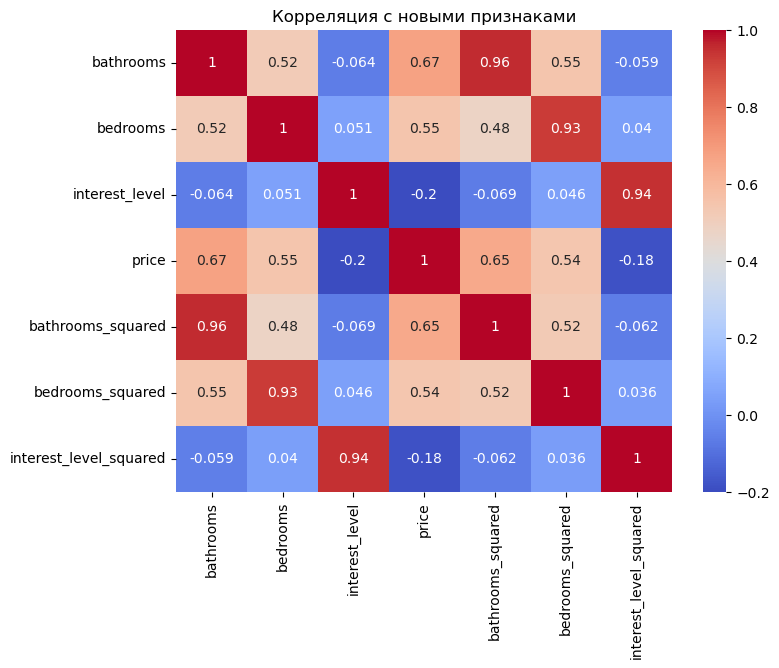

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляция с новыми признаками')
plt.show()

**Признаки в квадрате имеют хорошую корреляцию, но не выше чем у обычных признаков.**

In [134]:
train = pd.read_json('data/train.json')
test = pd.read_json('data/test.json')

low = np.percentile(train['price'], 1)
high = np.percentile(train['price'], 99)

train = train[(train['price'] > low) & (train['price'] < high)]

X_train = train[['bathrooms', 'bedrooms']]
y_train = train['price']

low = np.percentile(test['price'], 1)
high = np.percentile(test['price'], 99)

cols = ['price', 'bathrooms', 'bedrooms']
for col in cols:
    low = np.percentile(test[col], 1)
    high = np.percentile(test[col], 99)
    test = test[(test[col] > low) & (test[col] < high)]

X_test = test[['bathrooms', 'bedrooms']]
y_test = test['price']

In [135]:

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

## 5) Models

In [136]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

#### Linear Regression

In [137]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_poly, y_train)

y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

train['pred_lr'] = y_train_pred
test['pred_lr'] = y_test_pred

In [138]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

result_MAE.loc[len(result_MAE)] = [
    'linreg',
    f"{mae_train:.6f}",
    f"{mae_test:.6f}"
]

result_RMSE.loc[len(result_RMSE)] = [
    'linreg',
    f"{rmse_train:.6f}",
    f"{rmse_test:.6f}"
]

In [139]:
result_MAE

,model,train,test
0,linreg,753.675999,1198.223985


In [140]:
result_RMSE

,model,train,test
0,linreg,1070.598967,1621.832141


#### Decision Tree

In [141]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

tree = DecisionTreeRegressor(random_state=21)
tree.fit(X_train, y_train)

y_train_pred_tree = tree.predict(X_train)
y_test_pred_tree = tree.predict(X_test)

train['pred_tree'] = y_train_pred_tree
test['pred_tree'] = y_test_pred_tree


In [142]:

mae_train_tree = mean_absolute_error(y_train, y_train_pred_tree)
mae_test_tree = mean_absolute_error(y_test, y_test_pred_tree)

rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_train_pred_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_test_pred_tree))

result_MAE.loc[len(result_MAE)] = [
    'tree',
    f"{mae_train_tree:.6f}",
    f"{mae_test_tree:.6f}"
]

result_RMSE.loc[len(result_RMSE)] = [
    'tree',
    f"{rmse_train_tree:.6f}",
    f"{rmse_test_tree:.6f}"
]

In [143]:
print(result_MAE)
print()
print(result_RMSE)

    model       train         test
0  linreg  753.675999  1198.223985
1    tree  753.675997  1198.223989

    model        train         test
0  linreg  1070.598967  1621.832141
1    tree  1070.598967  1621.832141


#### Naive Models

In [144]:
mean_train = y_train.mean()
mean_test = y_test.mean()

train['pred_mean'] = mean_train
test['pred_mean'] = mean_test

mae_train_mean = mean_absolute_error(y_train, train['pred_mean'])
mae_test_mean = mean_absolute_error(y_test, test['pred_mean'])

rmse_train_mean = np.sqrt(mean_squared_error(y_train, train['pred_mean']))
rmse_test_mean = np.sqrt(mean_squared_error(y_test, test['pred_mean']))

result_MAE.loc[len(result_MAE)] = [ 'mean', f"{mae_train_mean:.6f}", f"{mae_test_mean:.6f}"]

result_RMSE.loc[len(result_RMSE)] = [ 'mean', f"{rmse_train_mean:.6f}", f"{rmse_test_mean:.6f}"]


In [145]:
median_train = y_train.median()
median_test = y_test.median()

train['pred_median'] = median_train
test['pred_median'] = median_test

mae_train_median = mean_absolute_error(y_train, train['pred_median'])
mae_test_median = mean_absolute_error(y_test, test['pred_median'])

rmse_train_median = np.sqrt(mean_squared_error(y_train, train['pred_median']))
rmse_test_median = np.sqrt(mean_squared_error(y_test, test['pred_median']))

result_MAE.loc[len(result_MAE)] = [ 'median', f"{mae_train_median:.6f}", f"{mae_test_median:.6f}"]

result_RMSE.loc[len(result_RMSE)] = [ 'median', f"{rmse_train_median:.6f}", f"{rmse_test_median:.6f}"]

print("result_MAE:")
result_MAE

result_MAE:


,model,train,test
0,linreg,753.675999,1198.223985
1,tree,753.675997,1198.223989
2,mean,1134.361473,1276.968159
3,median,1082.220859,1265.536913


In [146]:
print("result_RMSE:")
result_RMSE

result_RMSE:


,model,train,test
0,linreg,1070.598967,1621.832141
1,tree,1070.598967,1621.832141
2,mean,1585.609099,1709.845421
3,median,1631.719953,1721.506700
